In [1]:
import pandas as pd
import numpy as np

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [2]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [3]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [4]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [5]:
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"]
    - fraud_df["signup_time"]
).dt.total_seconds()

In [6]:
fraud_df["time_since_signup"].describe()

count    1.511120e+05
mean     4.932029e+06
std      3.126263e+06
min      1.000000e+00
25%      2.186754e+06
50%      4.926346e+06
75%      7.644524e+06
max      1.036797e+07
Name: time_since_signup, dtype: float64

In [7]:
fraud_df["hour_of_day"] = (
    fraud_df["purchase_time"]
    .dt.hour
)

In [8]:
fraud_df["hour_of_day"].value_counts().sort_index()

hour_of_day
0     6186
1     6228
2     6338
3     6458
4     6050
5     6189
6     6380
7     6181
8     6387
9     6418
10    6100
11    6327
12    6403
13    6292
14    6355
15    6369
16    6309
17    6466
18    6252
19    6299
20    6221
21    6224
22    6358
23    6322
Name: count, dtype: int64

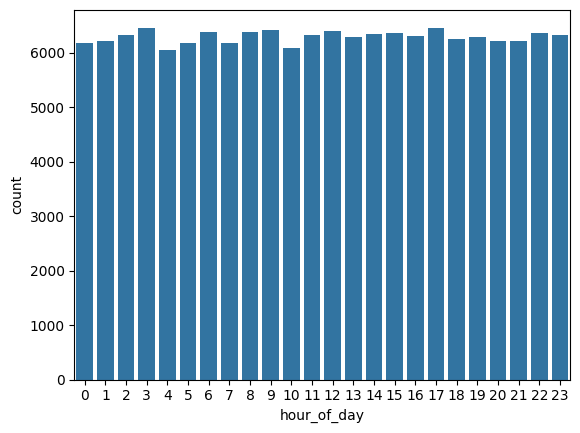

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=fraud_df,
    x="hour_of_day"
)

plt.show()

In [10]:
fraud_df["day_of_week"] = (
    fraud_df["purchase_time"]
    .dt.dayofweek
)

In [11]:
fraud_df["day_name"] = (
    fraud_df["purchase_time"]
    .dt.day_name()
)

In [12]:
fraud_df["day_name"].value_counts()

day_name
Sunday       22015
Monday       21711
Saturday     21648
Thursday     21586
Friday       21522
Wednesday    21316
Tuesday      21314
Name: count, dtype: int64

In [13]:
fraud_df["transaction_count"] = (
    fraud_df.groupby("user_id")
    ["user_id"]
    .transform("count")
)

In [14]:
fraud_df["transaction_count"].describe()

count    151112.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: transaction_count, dtype: float64

In [15]:
fraud_df["device_transaction_count"] = (
    fraud_df.groupby("device_id")
    ["device_id"]
    .transform("count")
)

In [16]:
fraud_df = fraud_df.sort_values(
    ["user_id", "purchase_time"]
)

In [17]:
fraud_df["time_since_last_purchase"] = (
    fraud_df.groupby("user_id")
    ["purchase_time"]
    .diff()
    .dt.total_seconds()
)

In [18]:
fraud_df["time_since_last_purchase"] = (
    fraud_df["time_since_last_purchase"]
    .fillna(0)
)

In [19]:
new_features = [
    "time_since_signup",
    "hour_of_day",
    "day_of_week",
    "transaction_count",
    "device_transaction_count",
    "time_since_last_purchase"
]

fraud_df[new_features].head()

,time_since_signup,hour_of_day,day_of_week,transaction_count,device_transaction_count,time_since_last_purchase
116708,3564984.0,10,5,1,1,0.0
15108,10039879.0,21,5,1,1,0.0
46047,6667201.0,11,3,1,1,0.0
67650,371290.0,23,2,1,1,0.0
109067,4631485.0,20,2,1,1,0.0


In [20]:
fraud_df.to_csv(
    "../data/processed/fraud_feature_engineered.csv",
    index=False
)